# Part 3 — Molecular Featurization

**Goal:** Convert SMILES strings into numerical feature matrices that ML models can learn from.

We compute **three complementary fingerprint types** entirely with RDKit (no external Java tools):

| Feature set | Bits | What it encodes | Used for |
|---|---|---|---|
| ECFP6 (Morgan r=3) | 2048 | Circular substructures around each atom | Main ML features — literature standard |
| MACCS Keys | 167 | Predefined SMARTS substructures | SHAP interpretation (each bit has a name) |
| RDKit 2D descriptors | ~208 | Continuous physicochemical properties | Correlation filtering + ADMET context |

**Input:** `egfr_bioactivity_cleaned.csv` (output of Part 1)  
**Outputs:** `X_ecfp6.csv`, `X_maccs.csv`, `X_rdkit2d.csv`, `y_pchembl.csv`, `y_class.csv`

---
## 0. Installs & Imports

In [2]:
# Uncomment on first run in Colab:
# !pip install rdkit-pypi

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from rdkit import Chem
from rdkit.Chem import AllChem, MACCSkeys, Descriptors, rdMolDescriptors
from sklearn.feature_selection import VarianceThreshold

import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
print('All imports OK')

All imports OK


---
## 1. Load Cleaned Data

In [4]:
df = pd.read_csv('../data/processed/egfr_bioactivity_cleaned.csv')

print(f'Compounds loaded : {len(df):,}')
print(f'Columns          : {list(df.columns)}')
df.head(3)

Compounds loaded : 9,876
Columns          : ['molecule_chembl_id', 'canonical_smiles', 'inchi_key', 'pchembl_value', 'bioactivity_class', 'group_type']


,molecule_chembl_id,canonical_smiles,inchi_key,pchembl_value,bioactivity_class,group_type
0,CHEMBL268868,O=C1NC(=O)c2cc(Nc3ccccc3)c(Nc3ccccc3)cc21,AAALVYBICLMAMA-UHFFFAOYSA-N,6.52,active,single_entry
1,CHEMBL2029442,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc2c(n1)N(c1cccc(N)...,AAFHSECTTHOVFV-UHFFFAOYSA-N,6.32,active,single_entry
2,CHEMBL2048906,CC(=O)NCCn1ccc2ncnc(Nc3ccc(Oc4cccc5sncc45)c(Cl...,AAGKMGNYUYCEPD-UHFFFAOYSA-N,8.54,active,single_entry


In [5]:
# Quick sanity check — no nulls in the two columns we need
assert df['canonical_smiles'].notna().all(), 'Found null SMILES'
assert df['pchembl_value'].notna().all(),    'Found null pChEMBL'
print('Sanity checks passed.')

Sanity checks passed.


---
## 2. RDKit Molecule Objects

All three fingerprint functions need a valid `Mol` object.
We build them once here so we never parse SMILES twice.

In [6]:
def smiles_to_mol(smi):
    """Parse SMILES → RDKit Mol. Returns None for invalid SMILES."""
    try:
        mol = Chem.MolFromSmiles(smi)
        return mol  # already None if invalid
    except Exception:
        return None

df['mol'] = df['canonical_smiles'].apply(smiles_to_mol)

n_invalid = df['mol'].isna().sum()
if n_invalid > 0:
    print(f'WARNING: {n_invalid} invalid SMILES — dropping those rows')
    df = df[df['mol'].notna()].copy()
else:
    print(f'All {len(df):,} SMILES parsed successfully.')

All 9,876 SMILES parsed successfully.


---
## 3. Fingerprint 1 — ECFP6 (Morgan, radius=3)

**What it is:** Extended-Connectivity Fingerprint with radius 3 (= 6 bonds diameter).
Each bit represents a unique circular substructure around an atom.

**Why ECFP6 specifically:**
Vignaux et al. (2023) used ECFP6 as the feature set for their AChE benchmark
(SVR R²=0.81). DeepEGFR (2025) used PubChem + Klekota-Roth fingerprints.
ECFP6 at 2048 bits is the field-wide standard — it makes our results
directly comparable to published benchmarks.

**Output shape:** (n_compounds, 2048)

In [7]:
def compute_ecfp6(mol_series, n_bits=2048):
    """
    Compute ECFP6 (Morgan radius=3) fingerprints.
    Returns a DataFrame with integer bit columns.
    """
    rows = []
    for mol in mol_series:
        fp = AllChem.GetMorganFingerprintAsBitVect(
            mol, radius=3, nBits=n_bits
        )
        rows.append(list(fp))

    cols = [f'ecfp6_{i}' for i in range(n_bits)]
    return pd.DataFrame(rows, columns=cols, dtype=int)


X_ecfp6_raw = compute_ecfp6(df['mol'])
print(f'ECFP6 raw shape  : {X_ecfp6_raw.shape}')

ECFP6 raw shape  : (9876, 2048)


In [8]:
# ── Variance threshold: remove bits that are almost always 0 or always 1 ──
# For a binary bit with frequency p: variance = p*(1-p)
# threshold=0.05 keeps bits present in roughly 5–95% of compounds
sel_ecfp6 = VarianceThreshold(threshold=0.05)
sel_ecfp6.fit(X_ecfp6_raw)

X_ecfp6 = pd.DataFrame(
    sel_ecfp6.transform(X_ecfp6_raw),
    columns=X_ecfp6_raw.columns[sel_ecfp6.get_support()]
)

print(f'ECFP6 after VarianceThreshold(0.05): {X_ecfp6.shape}')
print(f'  Bits removed: {X_ecfp6_raw.shape[1] - X_ecfp6.shape[1]}')
X_ecfp6.head(2)

ECFP6 after VarianceThreshold(0.05): (9876, 339)
  Bits removed: 1709


,ecfp6_1,ecfp6_13,ecfp6_14,ecfp6_20,ecfp6_31,ecfp6_32,ecfp6_41,ecfp6_43,ecfp6_45,ecfp6_65,...,ecfp6_1962,ecfp6_1970,ecfp6_1984,ecfp6_1991,ecfp6_1993,ecfp6_2004,ecfp6_2009,ecfp6_2013,ecfp6_2017,ecfp6_2021
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,1,0


---
## 4. Fingerprint 2 — MACCS Keys

**What it is:** 167 structural keys, each defined by a SMARTS pattern
(e.g., bit 163 = 'aromatic ring present', bit 141 = 'H-bond acceptor').

**Why use it:**
Unlike ECFP6, every MACCS bit has a human-readable chemical meaning.
This makes it the best feature set for **SHAP interpretation** in Part 6:
you can say "the model's prediction is driven by the presence of an aromatic ring"
rather than "bit 1047".

**Output shape:** (n_compounds, 167)

In [9]:
def compute_maccs(mol_series):
    """
    Compute MACCS Keys (167 bits, each = a defined SMARTS substructure).
    Returns a DataFrame with integer bit columns.
    """
    rows = []
    for mol in mol_series:
        fp = MACCSkeys.GenMACCSKeys(mol)
        rows.append(list(fp))

    # MACCS keys are 1-indexed (bit 0 is unused), keep all 167
    cols = [f'maccs_{i}' for i in range(167)]
    return pd.DataFrame(rows, columns=cols, dtype=int)


X_maccs_raw = compute_maccs(df['mol'])
print(f'MACCS raw shape  : {X_maccs_raw.shape}')

MACCS raw shape  : (9876, 167)


In [10]:
# ── Variance threshold (same logic as ECFP6) ─────────────────────────────────
sel_maccs = VarianceThreshold(threshold=0.05)
sel_maccs.fit(X_maccs_raw)

X_maccs = pd.DataFrame(
    sel_maccs.transform(X_maccs_raw),
    columns=X_maccs_raw.columns[sel_maccs.get_support()]
)

print(f'MACCS after VarianceThreshold(0.05): {X_maccs.shape}')
print(f'  Bits removed: {X_maccs_raw.shape[1] - X_maccs.shape[1]}')
X_maccs.head(2)

MACCS after VarianceThreshold(0.05): (9876, 114)
  Bits removed: 53


,maccs_22,maccs_24,maccs_25,maccs_34,maccs_36,maccs_37,maccs_38,maccs_41,maccs_42,maccs_45,...,maccs_150,maccs_151,maccs_152,maccs_153,maccs_154,maccs_155,maccs_157,maccs_159,maccs_160,maccs_164
0,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,1,0,0,1,0,1
1,0,0,1,0,0,1,1,0,0,0,...,1,1,1,1,1,0,1,1,1,1


---
## 5. Fingerprint 3 — RDKit 2D Descriptors

**What it is:** ~208 continuous physicochemical properties computed by RDKit
(molecular weight, logP, TPSA, H-bond donors/acceptors, ring counts,
rotatable bonds, charge descriptors, etc.).

**Why use it:**
Unlike binary fingerprints, these are continuous values directly tied to
ADMET properties. They are the only feature set where
**Pearson correlation filtering makes scientific sense**
(correlating two continuous descriptors is meaningful;
correlating two binary bits is not).

**Output shape:** (n_compounds, ~150–180 after filtering)

In [11]:
def compute_rdkit2d(mol_series):
    """
    Compute all 2D RDKit descriptors (continuous values).
    Returns a DataFrame. Columns correspond to descriptor names.
    """
    # Get all descriptor names and their functions once
    descriptor_fns = Descriptors.descList  # list of (name, function) tuples

    rows = []
    for mol in mol_series:
        values = []
        for name, fn in descriptor_fns:
            try:
                values.append(fn(mol))
            except Exception:
                values.append(np.nan)
        rows.append(values)

    cols = [name for name, _ in descriptor_fns]
    return pd.DataFrame(rows, columns=cols, dtype=float)


print('Computing RDKit 2D descriptors... (may take ~1-2 min for large datasets)')
X_rdkit2d_raw = compute_rdkit2d(df['mol'])
print(f'RDKit 2D raw shape: {X_rdkit2d_raw.shape}')

Computing RDKit 2D descriptors... (may take ~1-2 min for large datasets)
RDKit 2D raw shape: (9876, 208)


In [12]:
# ── Step 1: Drop descriptors with any NaN values ─────────────────────────────
n_before = X_rdkit2d_raw.shape[1]
X_rdkit2d_clean = X_rdkit2d_raw.dropna(axis=1)
print(f'After dropping NaN columns: {X_rdkit2d_clean.shape[1]} (removed {n_before - X_rdkit2d_clean.shape[1]})')

# ── Step 2: Drop infinite values ─────────────────────────────────────────────
X_rdkit2d_clean = X_rdkit2d_clean.replace([np.inf, -np.inf], np.nan).dropna(axis=1)
print(f'After dropping Inf columns : {X_rdkit2d_clean.shape[1]}')

After dropping NaN columns: 196 (removed 12)
After dropping Inf columns : 196


In [13]:
# ── Step 3: Pearson correlation filter (appropriate for continuous descriptors)
# Remove one of any pair of descriptors with |correlation| > 0.95
# This is valid here because these are continuous values — unlike binary fingerprints.

corr_matrix = X_rdkit2d_clean.corr().abs()
upper_tri   = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

cols_to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > 0.95)] # Redundanci in chem tend to be around 0.8–0.9
X_rdkit2d = X_rdkit2d_clean.drop(columns=cols_to_drop)

print(f'After correlation filter (>0.95): {X_rdkit2d.shape[1]} descriptors') 
print(f'  Descriptors removed: {len(cols_to_drop)}')
X_rdkit2d.head(2)

After correlation filter (>0.95): 163 descriptors
  Descriptors removed: 33


,MaxEStateIndex,MinEStateIndex,MinAbsEStateIndex,qed,MolWt,NumRadicalElectrons,FpDensityMorgan1,FpDensityMorgan2,BalabanJ,BertzCT,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,11.970074,-0.372803,0.372803,0.631443,329.359,0.0,0.600000,1.000000,1.781739,874.935104,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,13.080495,-0.178833,0.178833,0.543424,474.569,0.0,1.028571,1.828571,1.445660,1241.886509,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


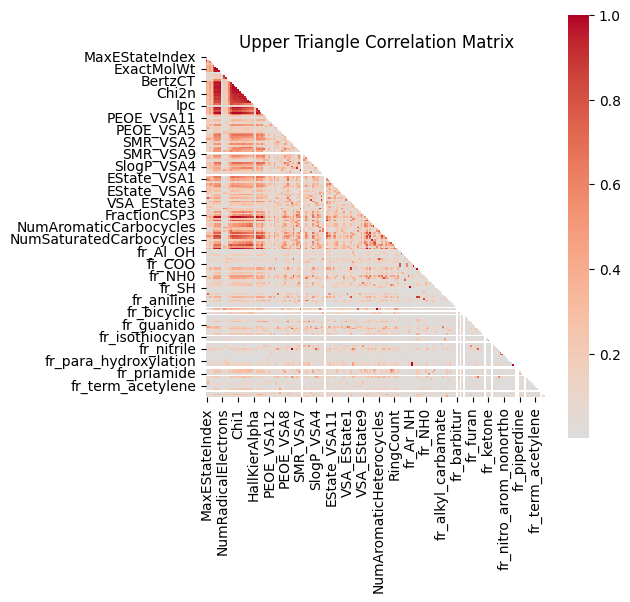

In [23]:
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(5.5, 5.5))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Upper Triangle Correlation Matrix")
plt.show()

In [19]:
high_corr = (
    upper_tri.stack()
    .reset_index()
)

high_corr.columns = ["Feature_1", "Feature_2", "Correlation"]

high_corr = high_corr[high_corr["Correlation"] > 0.95]
high_corr = high_corr.sort_values(by="Correlation", ascending=False)

print(high_corr.head(20))

                    Feature_1               Feature_2  Correlation
1              MaxEStateIndex       MaxAbsEStateIndex     1.000000
14742                  fr_COO                 fr_COO2     1.000000
14619                fr_Ar_NH            fr_Nhpyrrole     1.000000
911                     MolWt              ExactMolWt     0.999994
13149  NumAromaticCarbocycles              fr_benzene     0.999906
910                     MolWt          HeavyAtomMolWt     0.999019
1089           HeavyAtomMolWt              ExactMolWt     0.998927
3230                     Chi1          HeavyAtomCount     0.998798
16900               fr_phenol  fr_phenol_noOrthoHbond     0.997268
2729                     Chi0          HeavyAtomCount     0.996673
1450      NumValenceElectrons                    Chi0     0.996615
1525      NumValenceElectrons          HeavyAtomCount     0.996538
7951                 SMR_VSA2              fr_nitrile     0.996359
14726                fr_Ar_OH               fr_phenol     0.99

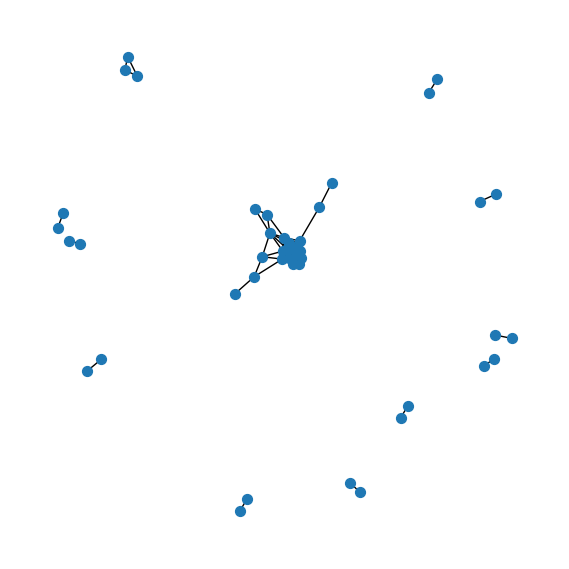

In [18]:
G = nx.Graph()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.95:
            G.add_edge(corr_matrix.columns[i], corr_matrix.columns[j])

plt.figure(figsize=(5.5, 5.5))
nx.draw(G, node_size=50, with_labels=False)
plt.show()

In [26]:
# Correlation AFTER filtering
corr_matrix_filtered = X_rdkit2d.corr(method="spearman").abs()

In [29]:
print("Max correlation remaining:", corr_matrix_filtered.values[np.triu_indices_from(corr_matrix_filtered, k=1)].max())

Max correlation remaining: nan


In [31]:
high_corr_post = (
    corr_matrix_filtered.where(
        np.triu(np.ones(corr_matrix_filtered.shape), k=1).astype(bool)
    )
    .stack()
    .reset_index()
)

high_corr_post.columns = ["Feature_1", "Feature_2", "Correlation"]

# Filtra threshold
high_corr_post = high_corr_post[high_corr_post["Correlation"] > 0.95]
high_corr_post = high_corr_post.sort_values(by="Correlation", ascending=False)

print(high_corr_post.head(20))

    Feature_1 Feature_2  Correlation
604     MolWt       Ipc     0.951164


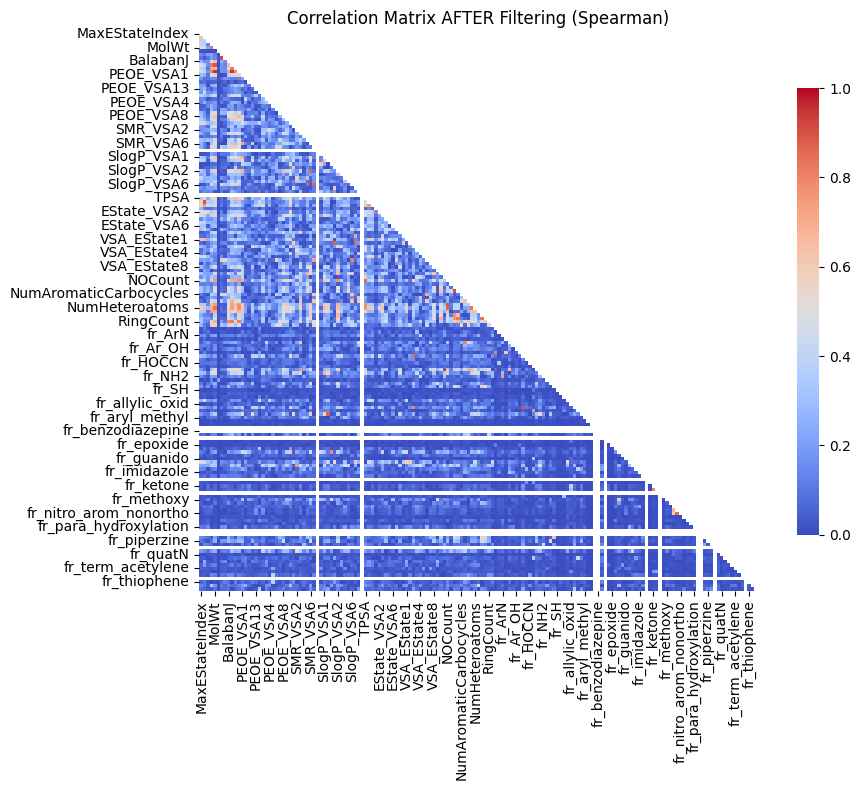

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

mask = np.triu(np.ones_like(corr_matrix_filtered, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix_filtered,
    mask=mask,
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix AFTER Filtering (Spearman)")
plt.tight_layout()
plt.show()

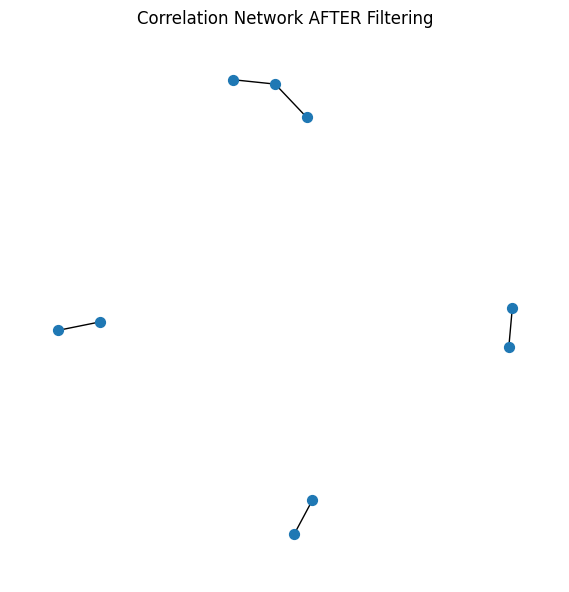

In [28]:
import networkx as nx

G = nx.Graph()

for i in range(len(corr_matrix_filtered.columns)):
    for j in range(i):
        if corr_matrix_filtered.iloc[i, j] > 0.9:
            G.add_edge(corr_matrix_filtered.columns[i], corr_matrix_filtered.columns[j])

plt.figure(figsize=(5.5, 5.5))
nx.draw(G, node_size=50, with_labels=False)
plt.title("Correlation Network AFTER Filtering")
plt.show()

---
## 6. Target Variables (Y)

Two target variables — one for regression, one for classification.

In [14]:
# Regression target: continuous pChEMBL value
y_pchembl = df[['molecule_chembl_id', 'pchembl_value']].reset_index(drop=True)

# Classification target: active / intermediate / inactive
y_class   = df[['molecule_chembl_id', 'bioactivity_class']].reset_index(drop=True)

# Binary classification target (active / inactive only — intermediates excluded)
y_binary  = y_class[y_class['bioactivity_class'] != 'intermediate'].copy()

print(f'y_pchembl shape  : {y_pchembl.shape}')
print(f'y_class shape    : {y_class.shape}  →  {y_class["bioactivity_class"].value_counts().to_dict()}')
print(f'y_binary shape   : {y_binary.shape}')

y_pchembl shape  : (9876, 2)
y_class shape    : (9876, 2)  →  {'active': 7439, 'intermediate': 1722, 'inactive': 715}
y_binary shape   : (8154, 2)


---
## 7. Feature Set Summary

Before saving, confirm all matrices have matching row counts.

In [15]:
summary = pd.DataFrame([
    ('ECFP6 (raw)',           X_ecfp6_raw.shape[0], X_ecfp6_raw.shape[1],  'binary bits'),
    ('ECFP6 (filtered)',      X_ecfp6.shape[0],     X_ecfp6.shape[1],      'binary bits'),
    ('MACCS keys (raw)',      X_maccs_raw.shape[0], X_maccs_raw.shape[1],  'binary bits'),
    ('MACCS keys (filtered)', X_maccs.shape[0],     X_maccs.shape[1],      'binary bits'),
    ('RDKit 2D (raw)',        X_rdkit2d_raw.shape[0],X_rdkit2d_raw.shape[1],'continuous'),
    ('RDKit 2D (filtered)',   X_rdkit2d.shape[0],   X_rdkit2d.shape[1],    'continuous'),
], columns=['Feature set', 'Rows', 'Columns', 'Type'])

print(summary.to_string(index=False))

# All row counts must match
assert X_ecfp6.shape[0] == X_maccs.shape[0] == X_rdkit2d.shape[0] == len(df), \
    'Row count mismatch — check for dropped compounds'
print('\nRow count check passed.')

          Feature set  Rows  Columns        Type
          ECFP6 (raw)  9876     2048 binary bits
     ECFP6 (filtered)  9876      339 binary bits
     MACCS keys (raw)  9876      167 binary bits
MACCS keys (filtered)  9876      114 binary bits
       RDKit 2D (raw)  9876      208  continuous
  RDKit 2D (filtered)  9876      163  continuous

Row count check passed.


---
## 8. Add Molecule ID Index & Save

We add `molecule_chembl_id` as a column (not the index) so that each CSV
is self-contained and can be merged back by ID later.

In [40]:
mol_ids = df['molecule_chembl_id'].reset_index(drop=True)

# Prepend the ID column to each feature matrix
def add_id(X, ids):
    return pd.concat([ids, X.reset_index(drop=True)], axis=1)

X_ecfp6_out  = add_id(X_ecfp6,  mol_ids)
X_maccs_out  = add_id(X_maccs,  mol_ids)
X_rdkit2d_out= add_id(X_rdkit2d,mol_ids)

# Save all outputs
X_ecfp6_out.to_csv('../data/processed/X_ecfp6.csv',    index=False)
X_maccs_out.to_csv('../data/processed/X_maccs.csv',    index=False)
X_rdkit2d_out.to_csv('../data/processed/X_rdkit2d.csv', index=False)
y_pchembl.to_csv('../data/processed/y_pchembl.csv',    index=False)
y_class.to_csv('../data/processed/y_class.csv',        index=False)
y_binary.to_csv('../data/processed/y_binary.csv',      index=False)

print('Saved:')
print(f'  X_ecfp6.csv   → {X_ecfp6_out.shape}')
print(f'  X_maccs.csv   → {X_maccs_out.shape}')
print(f'  X_rdkit2d.csv → {X_rdkit2d_out.shape}')
print(f'  y_pchembl.csv → {y_pchembl.shape}')
print(f'  y_class.csv   → {y_class.shape}')
print(f'  y_binary.csv  → {y_binary.shape}')

Saved:
  X_ecfp6.csv   → (9876, 340)
  X_maccs.csv   → (9876, 115)
  X_rdkit2d.csv → (9876, 164)
  y_pchembl.csv → (9876, 2)
  y_class.csv   → (9876, 2)
  y_binary.csv  → (8154, 2)


---
## 9. Quick Visual Check

Verify the feature distributions look sensible before moving to Part 4.

In [42]:
X_ecfp6_out

,molecule_chembl_id,ecfp6_1,ecfp6_13,ecfp6_14,ecfp6_20,ecfp6_31,ecfp6_32,ecfp6_41,ecfp6_43,ecfp6_45,...,ecfp6_1962,ecfp6_1970,ecfp6_1984,ecfp6_1991,ecfp6_1993,ecfp6_2004,ecfp6_2009,ecfp6_2013,ecfp6_2017,ecfp6_2021
0,CHEMBL268868,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,CHEMBL2029442,0,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
2,CHEMBL2048906,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,CHEMBL5757238,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,CHEMBL1240554,0,0,0,0,0,0,0,0,0,...,0,1,1,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9871,CHEMBL247710,0,0,0,0,0,1,0,1,0,...,1,1,0,0,0,0,0,0,0,0
9872,CHEMBL2178349,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9873,CHEMBL4570293,0,0,1,0,0,0,0,0,0,...,0,1,0,1,0,0,0,1,0,0
9874,CHEMBL2437476,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0


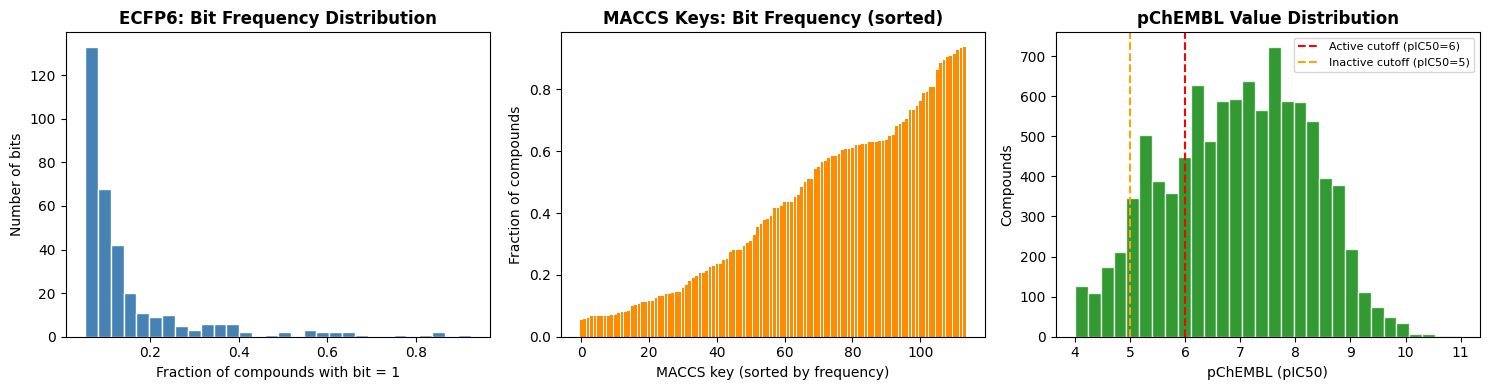

Figure saved as part3_feature_distributions.png


In [45]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ECFP6: bit frequency distribution
bit_freq_ecfp6 = X_ecfp6.mean()
axes[0].hist(bit_freq_ecfp6, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('ECFP6: Bit Frequency Distribution', fontweight='bold')
axes[0].set_xlabel('Fraction of compounds with bit = 1')
axes[0].set_ylabel('Number of bits')

# MACCS: bit frequency distribution
bit_freq_maccs = X_maccs.mean()
axes[1].bar(range(len(bit_freq_maccs)), sorted(bit_freq_maccs), color='darkorange')
axes[1].set_title('MACCS Keys: Bit Frequency (sorted)', fontweight='bold')
axes[1].set_xlabel('MACCS key (sorted by frequency)')
axes[1].set_ylabel('Fraction of compounds')

# pChEMBL distribution
axes[2].hist(y_pchembl['pchembl_value'], bins=30, color='green', edgecolor='white', alpha=0.8)
axes[2].axvline(x=6.0, color='red', linestyle='--', label='Active cutoff (pIC50=6)')
axes[2].axvline(x=5.0, color='orange', linestyle='--', label='Inactive cutoff (pIC50=5)')
axes[2].set_title('pChEMBL Value Distribution', fontweight='bold')
axes[2].set_xlabel('pChEMBL (pIC50)')
axes[2].set_ylabel('Compounds')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../figs/part3_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as part3_feature_distributions.png')

---
## Summary

| File | Shape | Used in |
|---|---|---|
| `X_ecfp6.csv` | (n, ~300–600) | Parts 4, 5 — main ML features |
| `X_maccs.csv` | (n, ~100–130) | Part 6 — SHAP explainability |
| `X_rdkit2d.csv` | (n, ~150–180) | Part 2 EDA / optional ML features |
| `y_pchembl.csv` | (n, 2) | Parts 4, 5 — regression target |
| `y_class.csv` | (n, 2) | Parts 4, 5 — 3-class target |
| `y_binary.csv` | (n, 2) | Parts 4, 5 — binary classification |

**Why VarianceThreshold and not correlation for ECFP6/MACCS?**  
Binary bits have variance `p*(1−p)`. A very low variance bit (e.g., present in <5% of compounds)
carries almost no information for the model — filtering it reduces noise.
Pearson correlation between binary bits is mathematically the phi coefficient;
it is sensitive to class imbalance and can give misleading results for rare bits,
so we do **not** apply correlation filtering to fingerprints.
Correlation filtering is only applied to the continuous RDKit 2D descriptors.